# Archivos Big Data

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

In [ ]:
!ls

drive	     spark-3.5.8-bin-hadoop3	  spark-3.5.8-bin-hadoop3.tgz.1
sample_data  spark-3.5.8-bin-hadoop3.tgz  spark-3.5.8-bin-hadoop3.tgz.2


In [ ]:
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
#spark = SparkSession.builder.master("local[*]").getOrCreate()
spark = SparkSession.builder \
                    .master("local[*]") \
                    .appName("Ejemplo") \
                    .getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = spark.read.csv(
    '/content/drive/MyDrive/Analisis_de_grandes_volumenes_de_datos/airbnb-listings.csv',
    header=True,
    sep=';',
    multiLine=True,          # para textos largos
    quote='"',               # maneja comillas
    escape='"',              # evita errores de parsing
    inferSchema=True
)
df.show(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
+--------+--------------------+--------------+------------+--------------------+--------------------+--------------------+--------------------+-------------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------+--------------------+--------------+----------+--------------------+--------------------+------------------+------------------+--------------------+--------------------+--------------------+------------------+-------------------+-------------------------+--------------------+--------------------+-------------+----------------------+----------------------------+---------+-------------+-------+---------+--------------------+------------+-----------+------------------+------------------

El dataset presentó problemas en la estructura debido a la presencia de saltos de línea dentro de campos de texto, lo que requirió el uso del parámetro multiLine=True en PySpark para una correcta lectura.

In [ ]:
#Información general
print("Número de registros:", df.count())
print("Número de columnas:", len(df.columns))
df.printSchema()

Número de registros: 494954
Número de columnas: 89
root
 |-- ID: string (nullable = true)
 |-- Listing Url: string (nullable = true)
 |-- Scrape ID: string (nullable = true)
 |-- Last Scraped: date (nullable = true)
 |-- Name: string (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Space: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Experiences Offered: string (nullable = true)
 |-- Neighborhood Overview: string (nullable = true)
 |-- Notes: string (nullable = true)
 |-- Transit: string (nullable = true)
 |-- Access: string (nullable = true)
 |-- Interaction: string (nullable = true)
 |-- House Rules: string (nullable = true)
 |-- Thumbnail Url: string (nullable = true)
 |-- Medium Url: string (nullable = true)
 |-- Picture Url: string (nullable = true)
 |-- XL Picture Url: string (nullable = true)
 |-- Host ID: integer (nullable = true)
 |-- Host URL: string (nullable = true)
 |-- Host Name: string (nullable = true)
 |-- Host Since: date (nulla

In [ ]:
df.show(10, vertical=True, truncate=False)

-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Se detectó que variables numéricas relevantes como precio, número de habitaciones y baños se encuentran almacenadas como texto, lo que requiere procesos adicionales de limpieza y transformación.

In [ ]:
#Estadísticas descriptivas
df.describe().show()

AnalysisException: [DATATYPE_MISMATCH.UNEXPECTED_INPUT_TYPE] Cannot resolve "element_at(Summary, summary)" due to data type mismatch: Parameter 1 requires the ("ARRAY" or "MAP") type, however "Summary" has the type "STRING".;
'Project [summary#17423, element_at(ID#15202, summary#17423, None, false) AS ID#15618, element_at(Listing Url#15207, summary#17423, None, false) AS Listing Url#15619, element_at(Scrape ID#15212, summary#17423, None, false) AS Scrape ID#15620, element_at(Name#15217, summary#17423, None, false) AS Name#15621, element_at(Summary#17423, summary#17423, None, false) AS Summary#15622, element_at(Space#15227, summary#17423, None, false) AS Space#15623, element_at(Description#15232, summary#17423, None, false) AS Description#15624, element_at(Experiences Offered#15237, summary#17423, None, false) AS Experiences Offered#15625, element_at(Neighborhood Overview#15242, summary#17423, None, false) AS Neighborhood Overview#15626, element_at(Notes#15247, summary#17423, None, fals

In [ ]:
#Valores nulos
from pyspark.sql.functions import col, sum

nulls = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

nulls.show()

nulls.toPandas().T.sort_values(by=0, ascending=False).head(10)

+---+-----------+---------+------------+----+-------+------+-----------+-------------------+---------------------+------+-------+------+-----------+-----------+-------------+----------+-----------+--------------+-------+--------+---------+----------+-------------+----------+------------------+------------------+--------------------+------------------+----------------+------------------+-------------------+-------------------------+------------------+------+-------------+----------------------+----------------------------+----+-----+-------+------+--------------+------------+-------+--------+---------+-------------+---------+------------+---------+--------+----+--------+---------+-----------+-----+------------+-------------+----------------+------------+---------------+------------+--------------+--------------+----------------+----------------+---------------+---------------+---------------+----------------+---------------------+-----------------+------------+-----------+--------------

,0
Has Availability,485647
Square Feet,482745
License,480358
Host Acceptance Rate,452696
Monthly Price,398863
Weekly Price,397207
Neighbourhood Group Cleansed,392791
Jurisdiction Names,360401
Notes,297291
Security Deposit,290942


Se identificó una alta proporción de valores nulos en múltiples variables, lo que indica posibles limitaciones en la recolección de datos o baja relevancia de ciertas variables para todos los registros.

## Transformación

In [ ]:
from pyspark.sql.functions import regexp_replace, col

df_clean = df \
    .withColumn("Bathrooms", col("Bathrooms").cast("float")) \
    .withColumn("Bedrooms", col("Bedrooms").cast("float")) \
    .withColumn("Accommodates", col("Accommodates").cast("int")) \
    .withColumn("Price", regexp_replace("Price", "[$,]", "").cast("float")) \
    .withColumn("Weekly Price", regexp_replace("Weekly Price", "[$,]", "").cast("float")) \
    .withColumn("Monthly Price", regexp_replace("Monthly Price", "[$,]", "").cast("float")) \
    .withColumn("Security Deposit", regexp_replace("Security Deposit", "[$,]", "").cast("float")) \
    .withColumn("Cleaning Fee", regexp_replace("Cleaning Fee", "[$,]", "").cast("float")) \
    .withColumn("Extra People", regexp_replace("Extra People", "[$,]", "").cast("float")) \
    .withColumn("Host Acceptance Rate", regexp_replace("Host Acceptance Rate", "%", "").cast("float")) \
    .withColumn("Host Response Rate", regexp_replace("Host Response Rate", "%", "").cast("float"))

In [ ]:
cols = [
    "Price",
    "Bedrooms",
    "Bathrooms",
    "Beds",
    "Accommodates",
    "Square Feet",
    "Number of Reviews",
    "Review Scores Rating",
    "Review Scores Cleanliness",
    "Review Scores Location",
    "Review Scores Value",
    "Host Acceptance Rate",
    "Host Response Rate",
    "Availability 30",
    "Availability 365",
    "Minimum Nights",
    "Maximum Nights"
]

In [ ]:
df_clean.select(cols).summary().show()

+-------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+--------------------+-------------------------+----------------------+-------------------+--------------------+------------------+-----------------+------------------+------------------+--------------------+
|summary|             Price|          Bedrooms|         Bathrooms|              Beds|      Accommodates|      Square Feet|Number of Reviews|Review Scores Rating|Review Scores Cleanliness|Review Scores Location|Review Scores Value|Host Acceptance Rate|Host Response Rate|  Availability 30|  Availability 365|    Minimum Nights|      Maximum Nights|
+-------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+--------------------+-------------------------+----------------------+-------------------+--------------------+------------------+-----------------+----------------

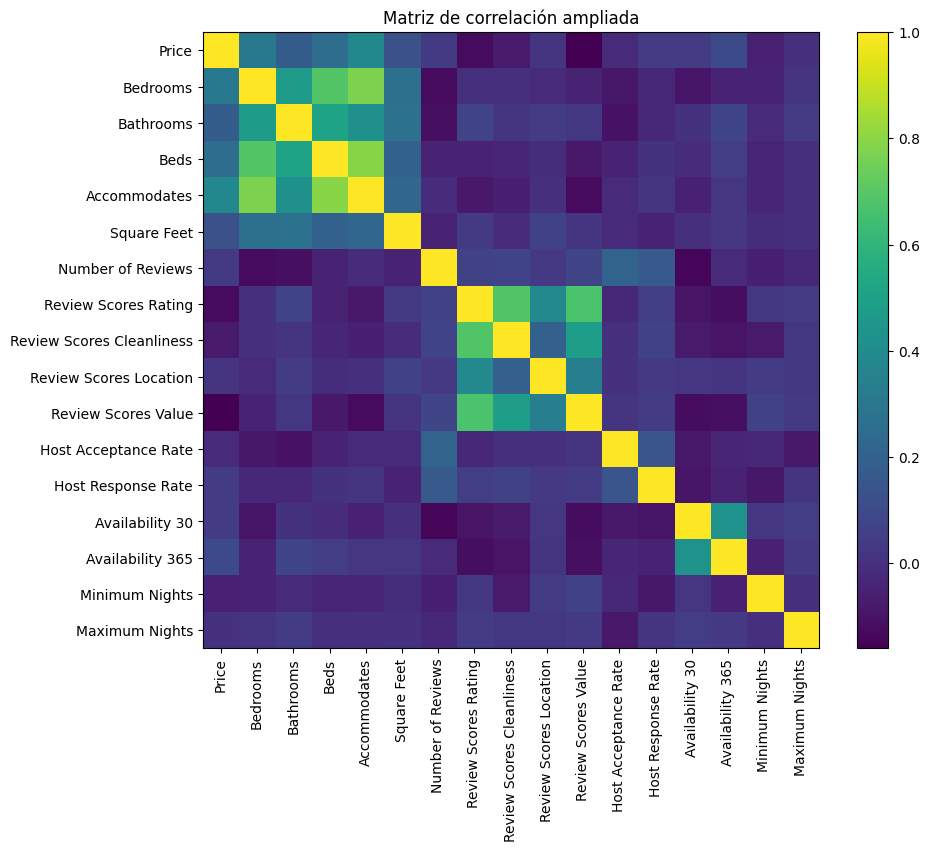

In [ ]:
import matplotlib.pyplot as plt

pdf = df_clean.select(cols).dropna().toPandas()
corr = pdf.corr()
corr

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlación ampliada")
plt.show()

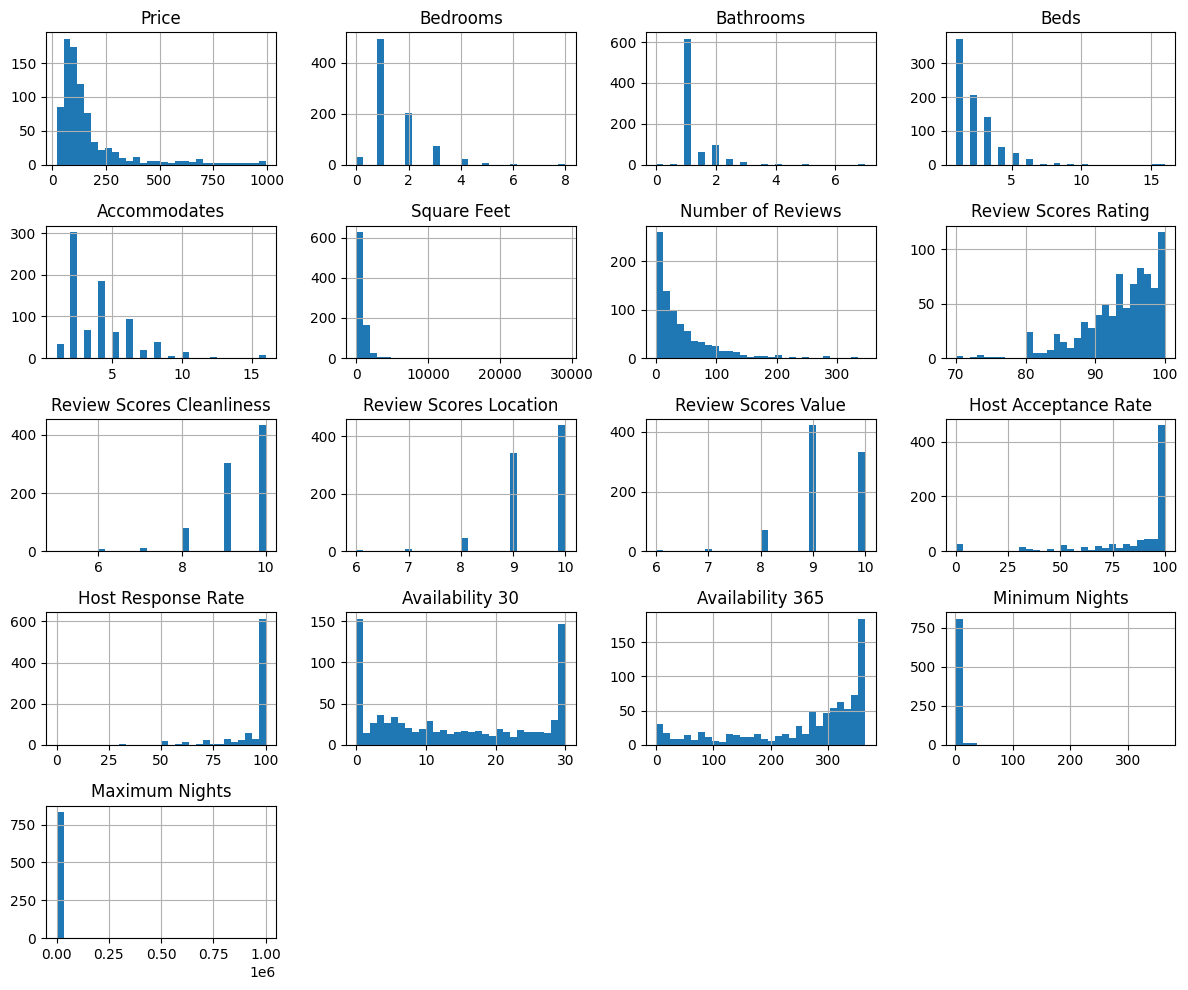

In [ ]:
pdf.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(pdf["Review Scores Rating"], pdf["Price"])
plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Precio vs rating")
plt.show()